In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/KL_dataset.xlsx')
# 1. Supprimer les colonnes non pertinentes
cols_to_drop = ['SampleNum', 'PatientNum', 'Timestamp', 'WardNum']
df_clean = df.drop(columns=cols_to_drop)

print("Colonnes après suppression:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

Colonnes après suppression: ['ERY', 'HK', 'LEUKO', 'HB', 'PLT', 'MCV', 'MCHC', 'MCH', 'RDW']
Shape: (523844, 9)


In [2]:
# 2. Vérifier les types — tout doit être numérique
df_clean.dtypes

ERY      float64
HK       float64
LEUKO    float64
HB       float64
PLT        int64
MCV      float64
MCHC     float64
MCH      float64
RDW      float64
dtype: object

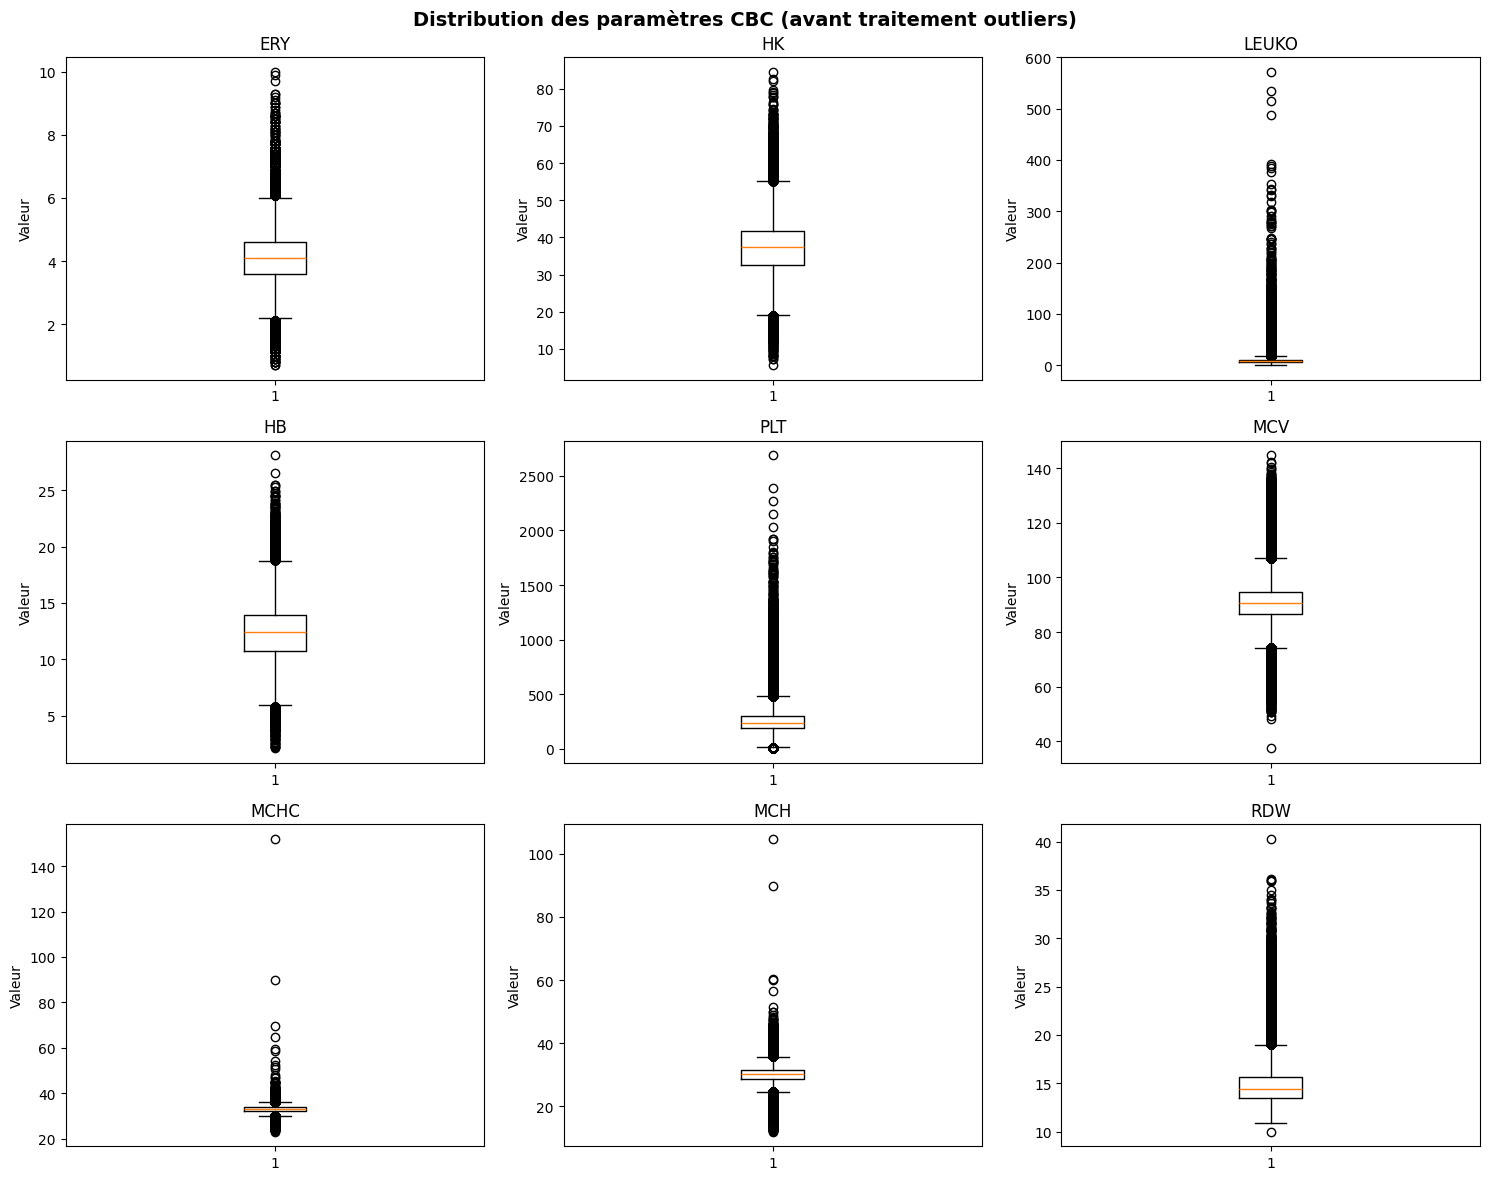

In [8]:
# 3. Visualiser les outliers avec boxplots AVANT traitement
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

cols_cbc = ['ERY', 'HK', 'LEUKO', 'HB', 'PLT', 'MCV', 'MCHC', 'MCH', 'RDW']

for i, col in enumerate(cols_cbc):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valeur')

plt.suptitle('Distribution des paramètres CBC (avant traitement outliers)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/boxplots_avant_traitement.png', dpi=150)
plt.show()

In [4]:
# 4. Quantifier les outliers par IQR — IMPORTANT pour le rapport
print("=" * 60)
print("ANALYSE DES OUTLIERS PAR IQR")
print("=" * 60)

outlier_summary = []

for col in cols_cbc:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = round(n_outliers / len(df_clean) * 100, 2)
    
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Borne inférieure': round(lower, 2),
        'Borne supérieure': round(upper, 2),
        'Nb outliers': n_outliers,
        '% outliers': pct
    })
    
    print(f"{col:8} | Bornes: [{lower:.2f}, {upper:.2f}] "
          f"| Outliers: {n_outliers} ({pct}%)")

df_outliers_summary = pd.DataFrame(outlier_summary)

ANALYSE DES OUTLIERS PAR IQR
ERY      | Bornes: [2.10, 6.10] | Outliers: 3838 (0.73%)
HK       | Bornes: [19.10, 55.10] | Outliers: 2651 (0.51%)
LEUKO    | Bornes: [-0.65, 17.35] | Outliers: 23712 (4.53%)
HB       | Bornes: [5.90, 18.70] | Outliers: 1506 (0.29%)
PLT      | Bornes: [10.50, 478.50] | Outliers: 21475 (4.1%)
MCV      | Bornes: [74.20, 107.00] | Outliers: 21249 (4.06%)
MCHC     | Bornes: [30.15, 36.15] | Outliers: 11870 (2.27%)
MCH      | Bornes: [24.50, 35.70] | Outliers: 24467 (4.67%)
RDW      | Bornes: [10.20, 19.00] | Outliers: 23136 (4.42%)


In [5]:
# 5. Décision sur les outliers
# ⚠️ ATTENTION — Ne pas supprimer les outliers médicaux trop agressivement
# car ils SONT les anomalies que l'on veut détecter !
# Stratégie : Capping (clipping) aux bornes médicales absolues

medical_bounds = {
    'ERY':  (0.5, 12.0),    # limites biologiquement possibles
    'HK':   (5.0, 75.0),
    'LEUKO':(0.1, 200.0),   # on garde les vraies leucémies
    'HB':   (1.0, 25.0),
    'PLT':  (1.0, 2000.0),
    'MCV':  (30.0, 140.0),
    'MCHC': (20.0, 45.0),   # >45 = erreur de mesure quasi certaine
    'MCH':  (10.0, 60.0),
    'RDW':  (9.0, 40.0)
}

df_clean_capped = df_clean.copy()

for col, (low, high) in medical_bounds.items():
    n_removed = ((df_clean_capped[col] < low) | 
                 (df_clean_capped[col] > high)).sum()
    df_clean_capped[col] = df_clean_capped[col].clip(lower=low, upper=high)
    print(f"{col}: {n_removed} valeurs hors bornes médicales → clippées")

print("\nShape finale:", df_clean_capped.shape)

ERY: 0 valeurs hors bornes médicales → clippées
HK: 13 valeurs hors bornes médicales → clippées
LEUKO: 52 valeurs hors bornes médicales → clippées
HB: 5 valeurs hors bornes médicales → clippées
PLT: 5 valeurs hors bornes médicales → clippées
MCV: 4 valeurs hors bornes médicales → clippées
MCHC: 15 valeurs hors bornes médicales → clippées
MCH: 3 valeurs hors bornes médicales → clippées
RDW: 1 valeurs hors bornes médicales → clippées

Shape finale: (523844, 9)


In [7]:
# 6. Sauvegarder les données nettoyées
df_clean_capped.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✅ Données nettoyées sauvegardées dans data/processed/cleaned_data.csv")

✅ Données nettoyées sauvegardées dans data/processed/cleaned_data.csv
